# NBA Trade Predictor Model
This notebook implements a Trade Predictor that uses predicted player outputs and Monte Carlo season simulations to estimate team-level outcomes (ΔWins, Playoff Probability, and Lineup Fit).

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import json
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [21]:
# 1. Load Data and Models
print("Loading data and models...")
player_df = pd.read_csv('../data/processed/player_features_v2_temporal.csv')
team_df = pd.read_csv('../data/processed/team_features_temporal.csv')


# Load trained models
player_model = joblib.load('../models/player_multioutput_v2.pkl')

print(f"Player data shape: {player_df.shape}")
print(f"Team data shape: {team_df.shape}")


Loading data and models...
Player data shape: (2564, 64)
Team data shape: (150, 29)


In [22]:
# 2. Data Preprocessing & Target Set Alignment
with open('../models/feature_names_v2.txt', 'r') as f:
    feature_cols = [line.strip() for line in f.readlines()]

with open('../models/target_names_v2.txt', 'r') as f:
    target_cols = [line.strip() for line in f.readlines()]

latest_player_data = player_df.sort_values(['player_name', 'season']).groupby('player_name').last().reset_index()


print(f"Latest player data prepared. Unique players: {len(latest_player_data)}")

Latest player data prepared. Unique players: 770


In [23]:
# 3. Generate Player Statistical Projections
print("Generating base player projections...")
X_inference = latest_player_data[feature_cols].fillna(0)
projections = player_model.predict(X_inference)

proj_df = pd.DataFrame(projections, columns=target_cols)
proj_df['player_name'] = latest_player_data['player_name']
proj_df['team'] = latest_player_data['team']
proj_df['position'] = latest_player_data['position']

# Default injury features (to be integrated later)
for col in ['minor_count', 'moderate_count', 'severe_count', 'prev_days_missed', 'prev_severe']:
    proj_df[col] = 0

std_devs = {
    'target_next_ppg': 3.0,
    'target_next_rpg': 1.2,
    'target_next_apg': 1.0,
    'target_next_mpg': 3.5,
    'target_next_ts_pct': 0.03
}

print("Projections ready with injury metadata.")

Generating base player projections...
Projections ready with injury metadata.


In [24]:
# 4. Fit Heuristics and Win Prediction

def calculate_fit_penalty(roster):
    penalty = 0
    pos_counts = roster['position'].value_counts()
    if pos_counts.get('PG', 0) > 3: penalty += 0.05
    if pos_counts.get('C', 0) > 3: penalty += 0.03
    
    top_scorers = roster.nlargest(3, 'target_next_ppg')['target_next_ppg'].sum()
    if top_scorers > 65: 
        penalty += 0.08
        
    return penalty

def calculate_team_score(roster, sampled_stats):
    top_8_stats = sampled_stats.nlargest(8, 'target_next_ppg')
    top_8_ppg = top_8_stats['target_next_ppg'].sum()
    efficiency_bonus = top_8_stats['target_next_ts_pct'].mean() * 10
    
    fit_penalty = calculate_fit_penalty(roster)
    
    score = (top_8_ppg + efficiency_bonus) * (1 - fit_penalty)
    return score

def predict_wins(score):
    wins = (score - 50) * 1.5 + 41
    return np.clip(wins, 0, 82)

def wins_to_playoff_prob(wins):
    if wins >= 42:
        return np.clip((wins - 42) * 0.1 + 0.5, 0.5, 1.0)
    else:
        return np.clip(0.5 - (42 - wins) * 0.1, 0.0, 0.5)

In [25]:
# 5. Monte Carlo Engine

def run_simulation(roster, n_sims=1000):
        injury_probs = np.full(len(roster), 0.05) # Placeholder injury risk
    
        results = []
        for _ in range(n_sims):
            sampled_stats = roster.copy()
            for col, std in std_devs.items():
                sampled_stats[col] = np.maximum(0, np.random.normal(roster[col], std))
            
            is_injured = np.random.random(len(roster)) < injury_probs
            sampled_stats.loc[is_injured, 'target_next_ppg'] *= 0.6
            
            score = calculate_team_score(roster, sampled_stats)
            wins = predict_wins(score)
            results.append(wins)
        
        return np.array(results)

In [26]:
# 6. Trade Scenario Handler

def analyze_trade(team_a_id, team_b_id, outgoing_a, outgoing_b):
    """
    Executes trade analysis between two teams.
    """
    # Get base rosters
    roster_a = proj_df[proj_df['team'] == team_a_id].copy()
    roster_b = proj_df[proj_df['team'] == team_b_id].copy()
    
    # Execute trade
    players_a = roster_a[roster_a['player_name'].isin(outgoing_a)]
    players_b = roster_b[roster_b['player_name'].isin(outgoing_b)]
    
    post_roster_a = pd.concat([roster_a[~roster_a['player_name'].isin(outgoing_a)], players_b])
    post_roster_b = pd.concat([roster_b[~roster_b['player_name'].isin(outgoing_b)], players_a])
    
    print(f"Analyzing trade for {team_a_id} and {team_b_id}...")
    
    results = {}
    for label, pre, post in [('Team A', roster_a, post_roster_a), ('Team B', roster_b, post_roster_b)]:
        print(f"Simulating {label}...")
        pre_wins = run_simulation(pre)
        post_wins = run_simulation(post)
        results[label] = (pre_wins, post_wins)
        
    return results

In [27]:
# 7. Visualization and Summary

def plot_trade_impact(results, team_a_name, team_b_name):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    for i, (label, team_name) in enumerate([('Team A', team_a_name), ('Team B', team_b_name)]):
        pre, post = results[label]
        sns.histplot(pre, color='gray', alpha=0.5, label='Pre-Trade', ax=axes[i], kde=True)
        sns.histplot(post, color='blue', alpha=0.5, label='Post-Trade', ax=axes[i], kde=True)
        
        axes[i].set_title(f"Win Distribution Impact: {team_name}")
        axes[i].set_xlabel("Expected Wins")
        axes[i].legend()
        
        delta = post.mean() - pre.mean()
        axes[i].axvline(pre.mean(), color='red', linestyle='--')
        axes[i].axvline(post.mean(), color='green', linestyle='-')
        
        print(f"{team_name} Expected Win Change: {delta:+.2f} wins")
        print(f"{team_name} Playoff Prob Change: {wins_to_playoff_prob(post.mean()) - wins_to_playoff_prob(pre.mean()):+.1%}")

    plt.show()


--- Trade Prediction Template ---
Available teams: <StringArray>
['MIL', 'TOR', 'ATL', 'WAS', 'DEN', 'HOU', 'IND', 'OKC', 'PHO', 'PHI', 'ORL',
 'BOS', 'MIA', 'CHO', 'LAL', 'CHI', 'LAC', 'GSW', 'POR', 'MIN', 'NOP', 'NYK',
 'BRK', 'DET', 'SAS', 'MEM', 'CLE', 'DAL', 'UTA', 'SAC']
Length: 30, dtype: str
LAL
GSW
LeBron James
Stephen Curry
Analyzing trade for LAL and GSW...
Simulating Team A...
Simulating Team B...
LAL Expected Win Change: +0.00 wins
LAL Playoff Prob Change: +0.0%
GSW Expected Win Change: +0.00 wins
GSW Playoff Prob Change: +0.0%


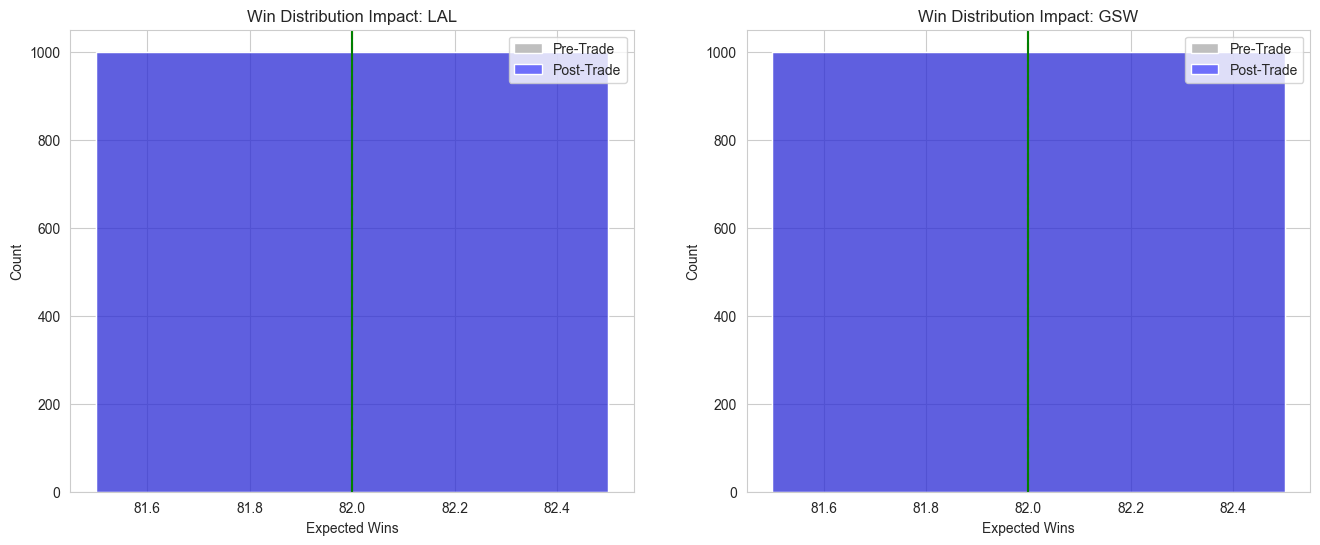

In [29]:
# 8. Interactive User Input (Template)
print("\n--- Trade Prediction Template ---")
print("Available teams:", proj_df['team'].unique())

# Example input flow (uncomment to test in notebook)
team_a = input("Proposing team (e.g., LAL): ")
team_b = input("Accepting team (e.g., BOS): ")
player_a = input("Player from Team A to trade: ")
player_b = input("Player from Team B to trade: ")

print(team_a)
print(team_b)
print(player_a)
print(player_b)
results = analyze_trade(team_a, team_b, [player_a], [player_b])
plot_trade_impact(results, team_a, team_b)